## 2D CSA - Vertical and Horizontal Strips

In [71]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:
# np.random.seed(42)

#### Data Simulation

In [73]:
def simulate_scores(n_phages, mean1, mean2, correlation, variance):
    """
    Simulates score for two different models
    """
    mean = [mean1, mean2]
   
    cov = [[variance, correlation * variance], [correlation * variance, variance]]  
    
    # Using absolute values to only have the postive quadrant
    scores = np.abs(np.random.multivariate_normal(mean, cov, n_phages))
    return np.clip(scores, 0, 1)

### Data Splitting

In [74]:
def split_calibration_data(scores, split_ratio):
    """
    Splits ths calibration scores
    """
    n = len(scores)
    indices = np.arange(n)
    np.random.shuffle(indices)  
    limit = int(n * split_ratio)
    # randomly splits the indices into 2 sets
    return scores[indices[:limit]], scores[indices[limit:]]

### Shape Discovery

In [75]:
def shape_discovery(shape_set_scores, alpha, M):
    """
    Discovers the shape of the non-convex region using strips (both horizontal and vertical) and quantiles
    """

    bin_edges = np.linspace(0, 1, M + 1)   # bins defined from 0 to 1
    x_limits = np.zeros(M)    # X-limits for the horizontal strips
    y_limits = np.zeros(M)    # Y-limits for the vertical strips
    
    # Calculating the boundaries
    for i in range(M):
        # Horizontal strips: X-quantile for points in a Y-range
        mask_y = (shape_set_scores[:, 1] >= bin_edges[i]) & (shape_set_scores[:, 1] < bin_edges[i+1])   # finds all the data points that fall in the currect Y-strip
        x_limits[i] = np.quantile(shape_set_scores[mask_y, 0], 1 - alpha) if np.any(mask_y) else 0   # finds the x value wherre 1-alpha of the points lie
            
        # Vertical strips: Y-quantile for points in an X-range
        mask_x = (shape_set_scores[:, 0] >= bin_edges[i]) & (shape_set_scores[:, 0] < bin_edges[i+1])
        y_limits[i] = np.quantile(shape_set_scores[mask_x, 1], 1 - alpha) if np.any(mask_x) else 0

    # Filling the gaps - ensures that we do not include regions with higher errors
    for i in range(M - 2, -1, -1):
        x_limits[i] = max(x_limits[i], x_limits[i+1])   # to ensure that the x-limits are non increasing as we move left to right
        y_limits[i] = max(y_limits[i], y_limits[i+1])   # to ensure that the y-limits are non increasing as we move bottom to top
            
    return bin_edges, x_limits, y_limits

### Size Scaling

In [76]:
def size_scaling(size_set_scores, bin_edges, x_limits, y_limits, alpha):
    """
    Calculates the final scaling factor t_hat that ensure the coverage guarantee
    The tau score for any point is the minimum scale that is needed for the point to fall in either the x or y bin
    """

    # Finding the bin indices (digitize gives the index of the strip that each point falls to)
    idx_y = np.clip(np.digitize(size_set_scores[:, 1], bin_edges) - 1, 0, len(x_limits)-1)  
    idx_x = np.clip(np.digitize(size_set_scores[:, 0], bin_edges) - 1, 0, len(y_limits)-1)
    
    # Calculating the tau ratios for both directions
    tau_x = size_set_scores[:, 0] / (x_limits[idx_y] + 1e-12)
    tau_y = size_set_scores[:, 1] / (y_limits[idx_x] + 1e-12)
    
    # We take the union to get the best scaling factor fro each point (the point is basically considered okay if 
    # it falls in either of the bounsaries)
    tau_scores = np.maximum(tau_x, tau_y)   # the minimum scaling factor for each point to be included in the shape
    
    # Quantile calculations to get t_hat 
    n2 = len(tau_scores)
    idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1  
    t_hat = np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]   # sorting all the ratios and finding the 1-alpha quantile to get the final scalign factor
    
    return t_hat, tau_scores

### Visualization

In [77]:
def get_mask(pts, bins, x_lims, y_lims, scale=1):
    """
    Tells us which points are inside the discovered shape and which are outside"""
    sx = x_lims * scale    # scaled x limits
    sy = y_lims * scale    # scales y limits

    iy = np.clip(np.digitize(pts[:, 1], bins) - 1, 0, len(sx)-1)    # bin indices for y
    ix = np.clip(np.digitize(pts[:, 0], bins) - 1, 0, len(sy)-1)    # bin indicies for x

    # a score point is inside if it is either under the x limit or the y limit (union of the two)
    # return (pts[:, 0] <= sx[iy]) | (pts[:, 1] <= sy[ix])
    return (pts[:, 0] <= sx[iy]) & (pts[:, 1] <= sy[ix])

In [78]:
def plot_csa_steps(scores, S1, S2, bin_edges, x_limits, y_limits, t_hat, alpha):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    x_range = np.linspace(0, 0.8, 200) 
    X, Y = np.meshgrid(x_range, x_range)
    grid = np.vstack([X.ravel(), Y.ravel()]).T

    # Plotting the original simulate_scores
    axs[0].scatter(scores[:, 0], scores[:, 1], color='black', alpha=0.5, s=10)
    axs[0].set_title('Score Distribution')
    
    # Plotting the discovered shape
    inside_shape = get_mask(grid, bin_edges, x_limits, y_limits).reshape(X.shape)
    axs[1].contourf(X, Y, inside_shape, levels=[0.5, 1], colors='blue', alpha=0.2)
    axs[1].contour(X, Y, inside_shape, levels=[0.5], colors='blue', linewidths=2)
    axs[1].scatter(S1[:, 0], S1[:, 1], s=5, color='blue', alpha=0.5)
    axs[1].set_title('Shape Discovery')

    # Final scaled envelope
    inside_final = get_mask(grid, bin_edges, x_limits, y_limits, t_hat).reshape(X.shape)
    axs[2].contourf(X, Y, inside_final, levels=[0.5, 1], colors='green', alpha=0.2)
    axs[2].contour(X, Y, inside_final, levels=[0.5], colors='green', linewidths=2)
    axs[2].contour(X, Y, inside_shape, levels=[0.5], colors='blue', linestyles='--', linewidths=1)
    axs[2].scatter(S2[:, 0], S2[:, 1], s=5, color='green', alpha=0.5)
    axs[2].set_title(f'Final Calibrated Region (t={t_hat:.2f})')

    for ax in axs:
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


### Execution

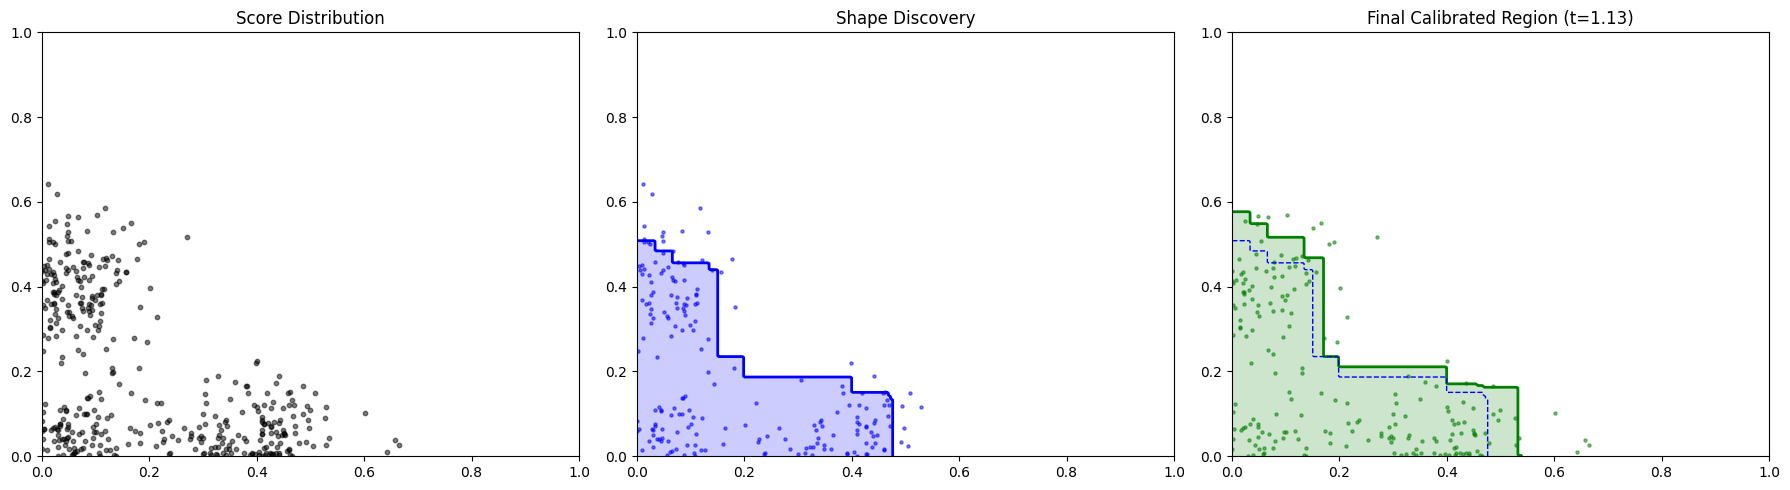

In [79]:
alpha = 0.1 
M = 30     

# Simulating the scores (L-shaped)
origin = simulate_scores(100, mean1=0.0, mean2=0.0, correlation=0, variance=0.01)
# Model 1 accurate, Model 2 failing
arm_y = simulate_scores(150, mean1=0.0, mean2=0.4, correlation=0, variance=0.007)
# Model 2 accurate, Model 1 failing
arm_x = simulate_scores(150, mean1=0.4, mean2=0.0, correlation=0, variance=0.007)
raw_scores = np.vstack([origin, arm_y, arm_x])

# # Simulating scores (correlated = diagonal)
# raw_scores = simulate_scores(500, mean1 = 0.3, mean2 = 0.3, correlation= 0.8, variance = 0.02)

S1, S2 = split_calibration_data(raw_scores, split_ratio=0.5)
bin_edges, x_limits, y_limits = shape_discovery(S1, alpha, M)
t_hat, _ = size_scaling(S2, bin_edges, x_limits, y_limits, alpha)

plot_csa_steps(raw_scores, S1, S2, bin_edges, x_limits, y_limits, t_hat, alpha)

In [80]:
# Cheching the actual coverage on the seconf set
mask = get_mask(S2, bin_edges, x_limits, y_limits, t_hat)
actual_coverage = np.mean(mask)
print(f"Actual Coverage: {actual_coverage:.4f}")

Actual Coverage: 0.9000
